# Experiment 1 — statistical analysis

Three complementary analyses, following Demšar (2006), García & Herrera (2008) and the benchmarking literature (Fernández-Delgado et al., 2014):

1. **PAMA** — *Probability of Achieving MAximal accuracy*: the relative frequency with which each learner achieves the TOP score across all fold-level observations. Descriptive dominance, no distributional assumptions.
2. **Friedman test + Iman–Davenport correction** — the omnibus test: are the rank differences globally non-random? Only if it rejects are post-hoc comparisons warranted. Visualised with **Nemenyi critical-difference diagrams**.
3. **Pairwise Wilcoxon signed-rank tests with Holm step-down correction** over ALL method pairs, reported as a **Win/Loss matrix** (a trailing `*` marks pairs significant at α = 0.05 after Holm).

PD uses **AUC**; LGD uses **R²**. Tests over datasets use one fold-mean per dataset; PAMA uses every (dataset, fold) observation.
All logic: `src/utils/statistical_testing.py`. Figures → `figures/experiment1/stats/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, method_ranking_bars, learning_curve, imbalance_curve,
    metric_boxplots, metric_bars, median_time_bars, rank_heatmap, rank_boxplots,
    hpo_improvement_bars, runtime_performance_scatter,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1/stats')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment1\stats


In [2]:
from src.utils import statistical_testing as st
from src.methods.method_config import FOUNDATION_METHODS
df_pd       = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd')
df_pd_folds = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd',  aggregated=False)
try:
    df_lgd       = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd')
    df_lgd_folds = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False)
except FileNotFoundError:
    df_lgd = df_lgd_folds = None

## 1. PAMA — who wins the fold-level observations?

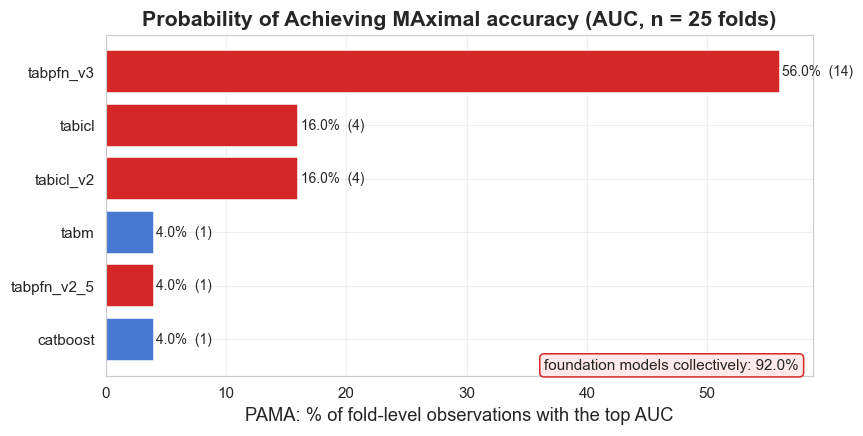

,wins,n_folds,PAMA_%
method,,,
tabpfn_v3,14,25,56.0
tabicl,4,25,16.0
tabicl_v2,4,25,16.0
tabm,1,25,4.0
tabpfn_v2_5,1,25,4.0
catboost,1,25,4.0
LogReg,0,25,0.0
switchtab,0,25,0.0
t2gformer,0,25,0.0


In [3]:
st.plot_pama_bars(df_pd_folds, 'AUC', metric_name='AUC',
                  foundation_methods=sorted(FOUNDATION_METHODS),
                  out_path=FIGURES_DIR / 'pd_pama_auc.pdf')
display(st.pama_fold_level(df_pd_folds, 'AUC').head(15))

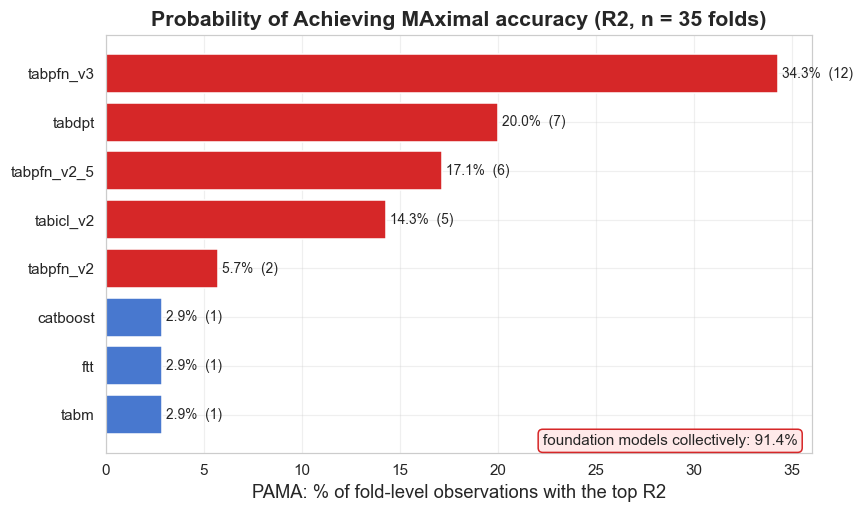

,wins,n_folds,PAMA_%
method,,,
tabpfn_v3,12,35,34.285714
tabdpt,7,35,20.000000
tabpfn_v2_5,6,35,17.142857
tabicl_v2,5,35,14.285714
tabpfn_v2,2,35,5.714286
catboost,1,35,2.857143
ftt,1,35,2.857143
tabm,1,35,2.857143
LinearRegression,0,35,0.000000


In [4]:
if df_lgd_folds is not None:
    st.plot_pama_bars(df_lgd_folds, 'R2', metric_name='R2',
                      foundation_methods=sorted(FOUNDATION_METHODS),
                      out_path=FIGURES_DIR / 'lgd_pama_r2.pdf')
    display(st.pama_fold_level(df_lgd_folds, 'R2').head(15))

## 2. Friedman omnibus test (Iman–Davenport corrected)

In [5]:
mat_pd = st.metric_matrix(df_pd, 'AUC')
f_pd = st.friedman_test(mat_pd)
print(f"PD  (N={f_pd['N']} datasets, k={f_pd['k']} methods): "
      f"F_F = {f_pd['iman_davenport_F']:.2f}, p = {f_pd['p_iman_davenport']:.3g}")
if df_lgd is not None:
    mat_lgd = st.metric_matrix(df_lgd, 'R2')
    f_lgd = st.friedman_test(mat_lgd)
    print(f"LGD (N={f_lgd['N']} datasets, k={f_lgd['k']} methods): "
          f"F_F = {f_lgd['iman_davenport_F']:.2f}, p = {f_lgd['p_iman_davenport']:.3g}")

[stat] dropping methods with missing datasets: ['autoint', 'tabpfn_real', 'tabpfn_v2']
PD  (N=14 datasets, k=31 methods): F_F = 18.08, p = 1.79e-56
LGD (N=7 datasets, k=25 methods): F_F = 8.01, p = 1.18e-16


### Nemenyi critical-difference diagrams
Methods joined by a bold bar are NOT significantly different at α = 0.05.

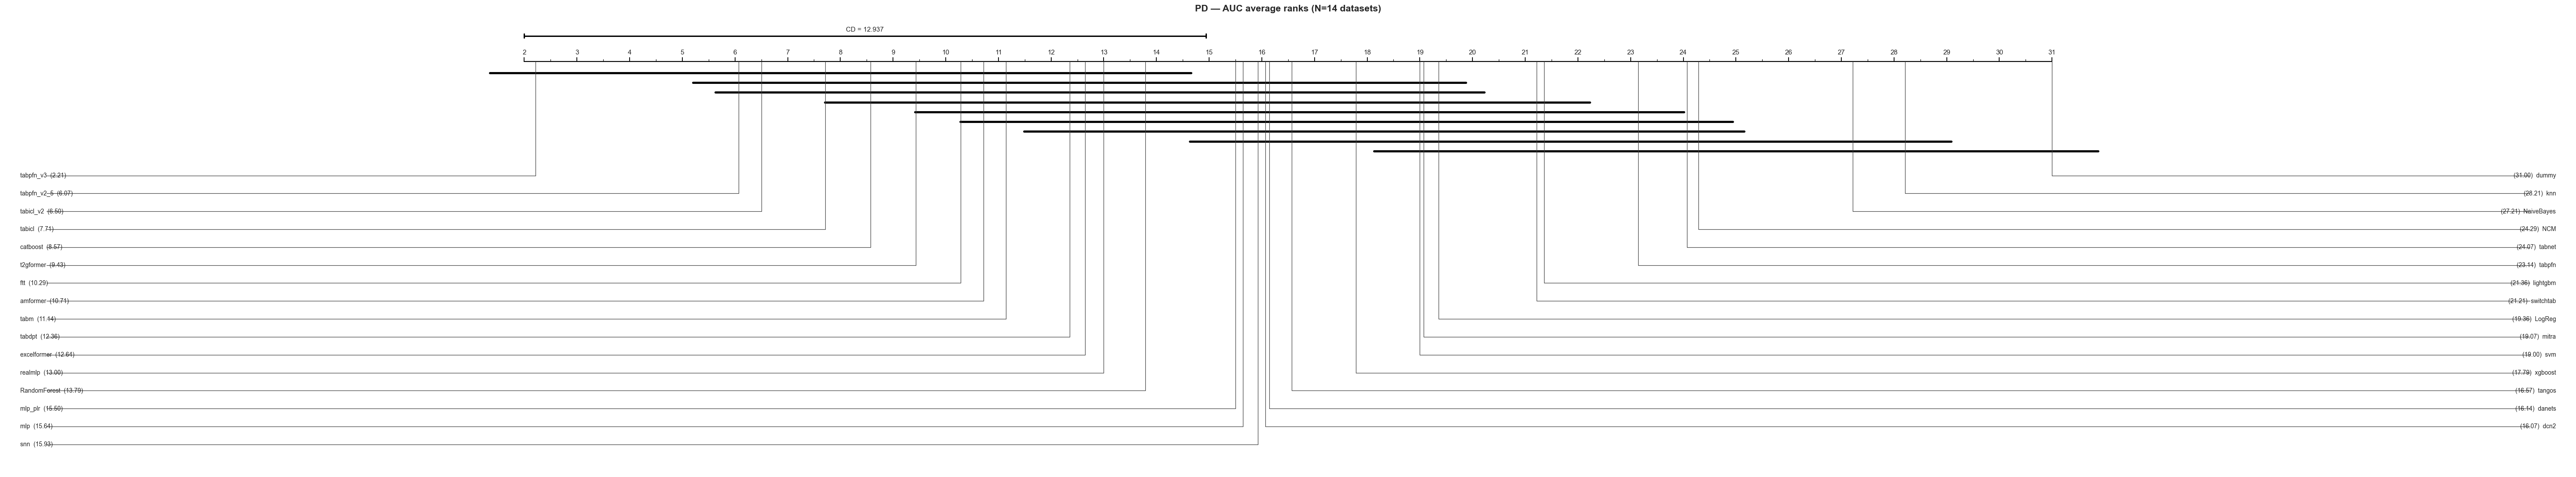

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/stats/pd_cd_diagram_auc.pdf')

In [6]:
st.plot_cd_diagram(st.average_ranks(mat_pd),
                   st.nemenyi_cd(mat_pd.shape[1], mat_pd.shape[0]),
                   title=f'PD — AUC average ranks (N={mat_pd.shape[0]} datasets)',
                   out_path=FIGURES_DIR / 'pd_cd_diagram_auc.pdf')

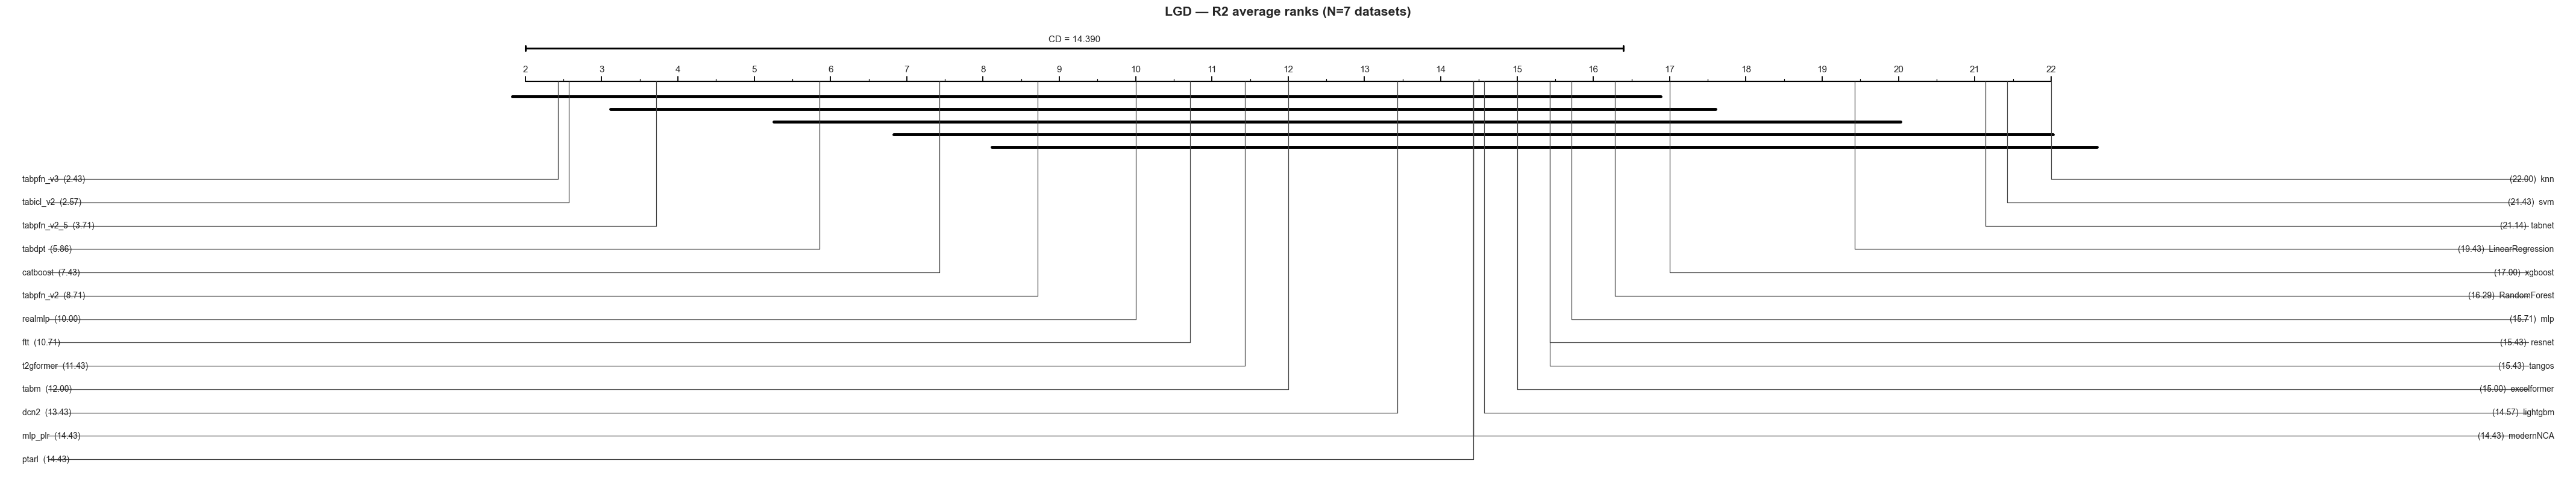

In [7]:
if df_lgd is not None:
    st.plot_cd_diagram(st.average_ranks(mat_lgd),
                       st.nemenyi_cd(mat_lgd.shape[1], mat_lgd.shape[0]),
                       title=f'LGD — R2 average ranks (N={mat_lgd.shape[0]} datasets)',
                       out_path=FIGURES_DIR / 'lgd_cd_diagram_r2.pdf')

## 3. Pairwise Wilcoxon signed-rank tests, Holm-corrected
Cell text = Win/Loss of the row method vs the column method across datasets; `*` = significant after Holm (α = 0.05, corrected over all pairs).

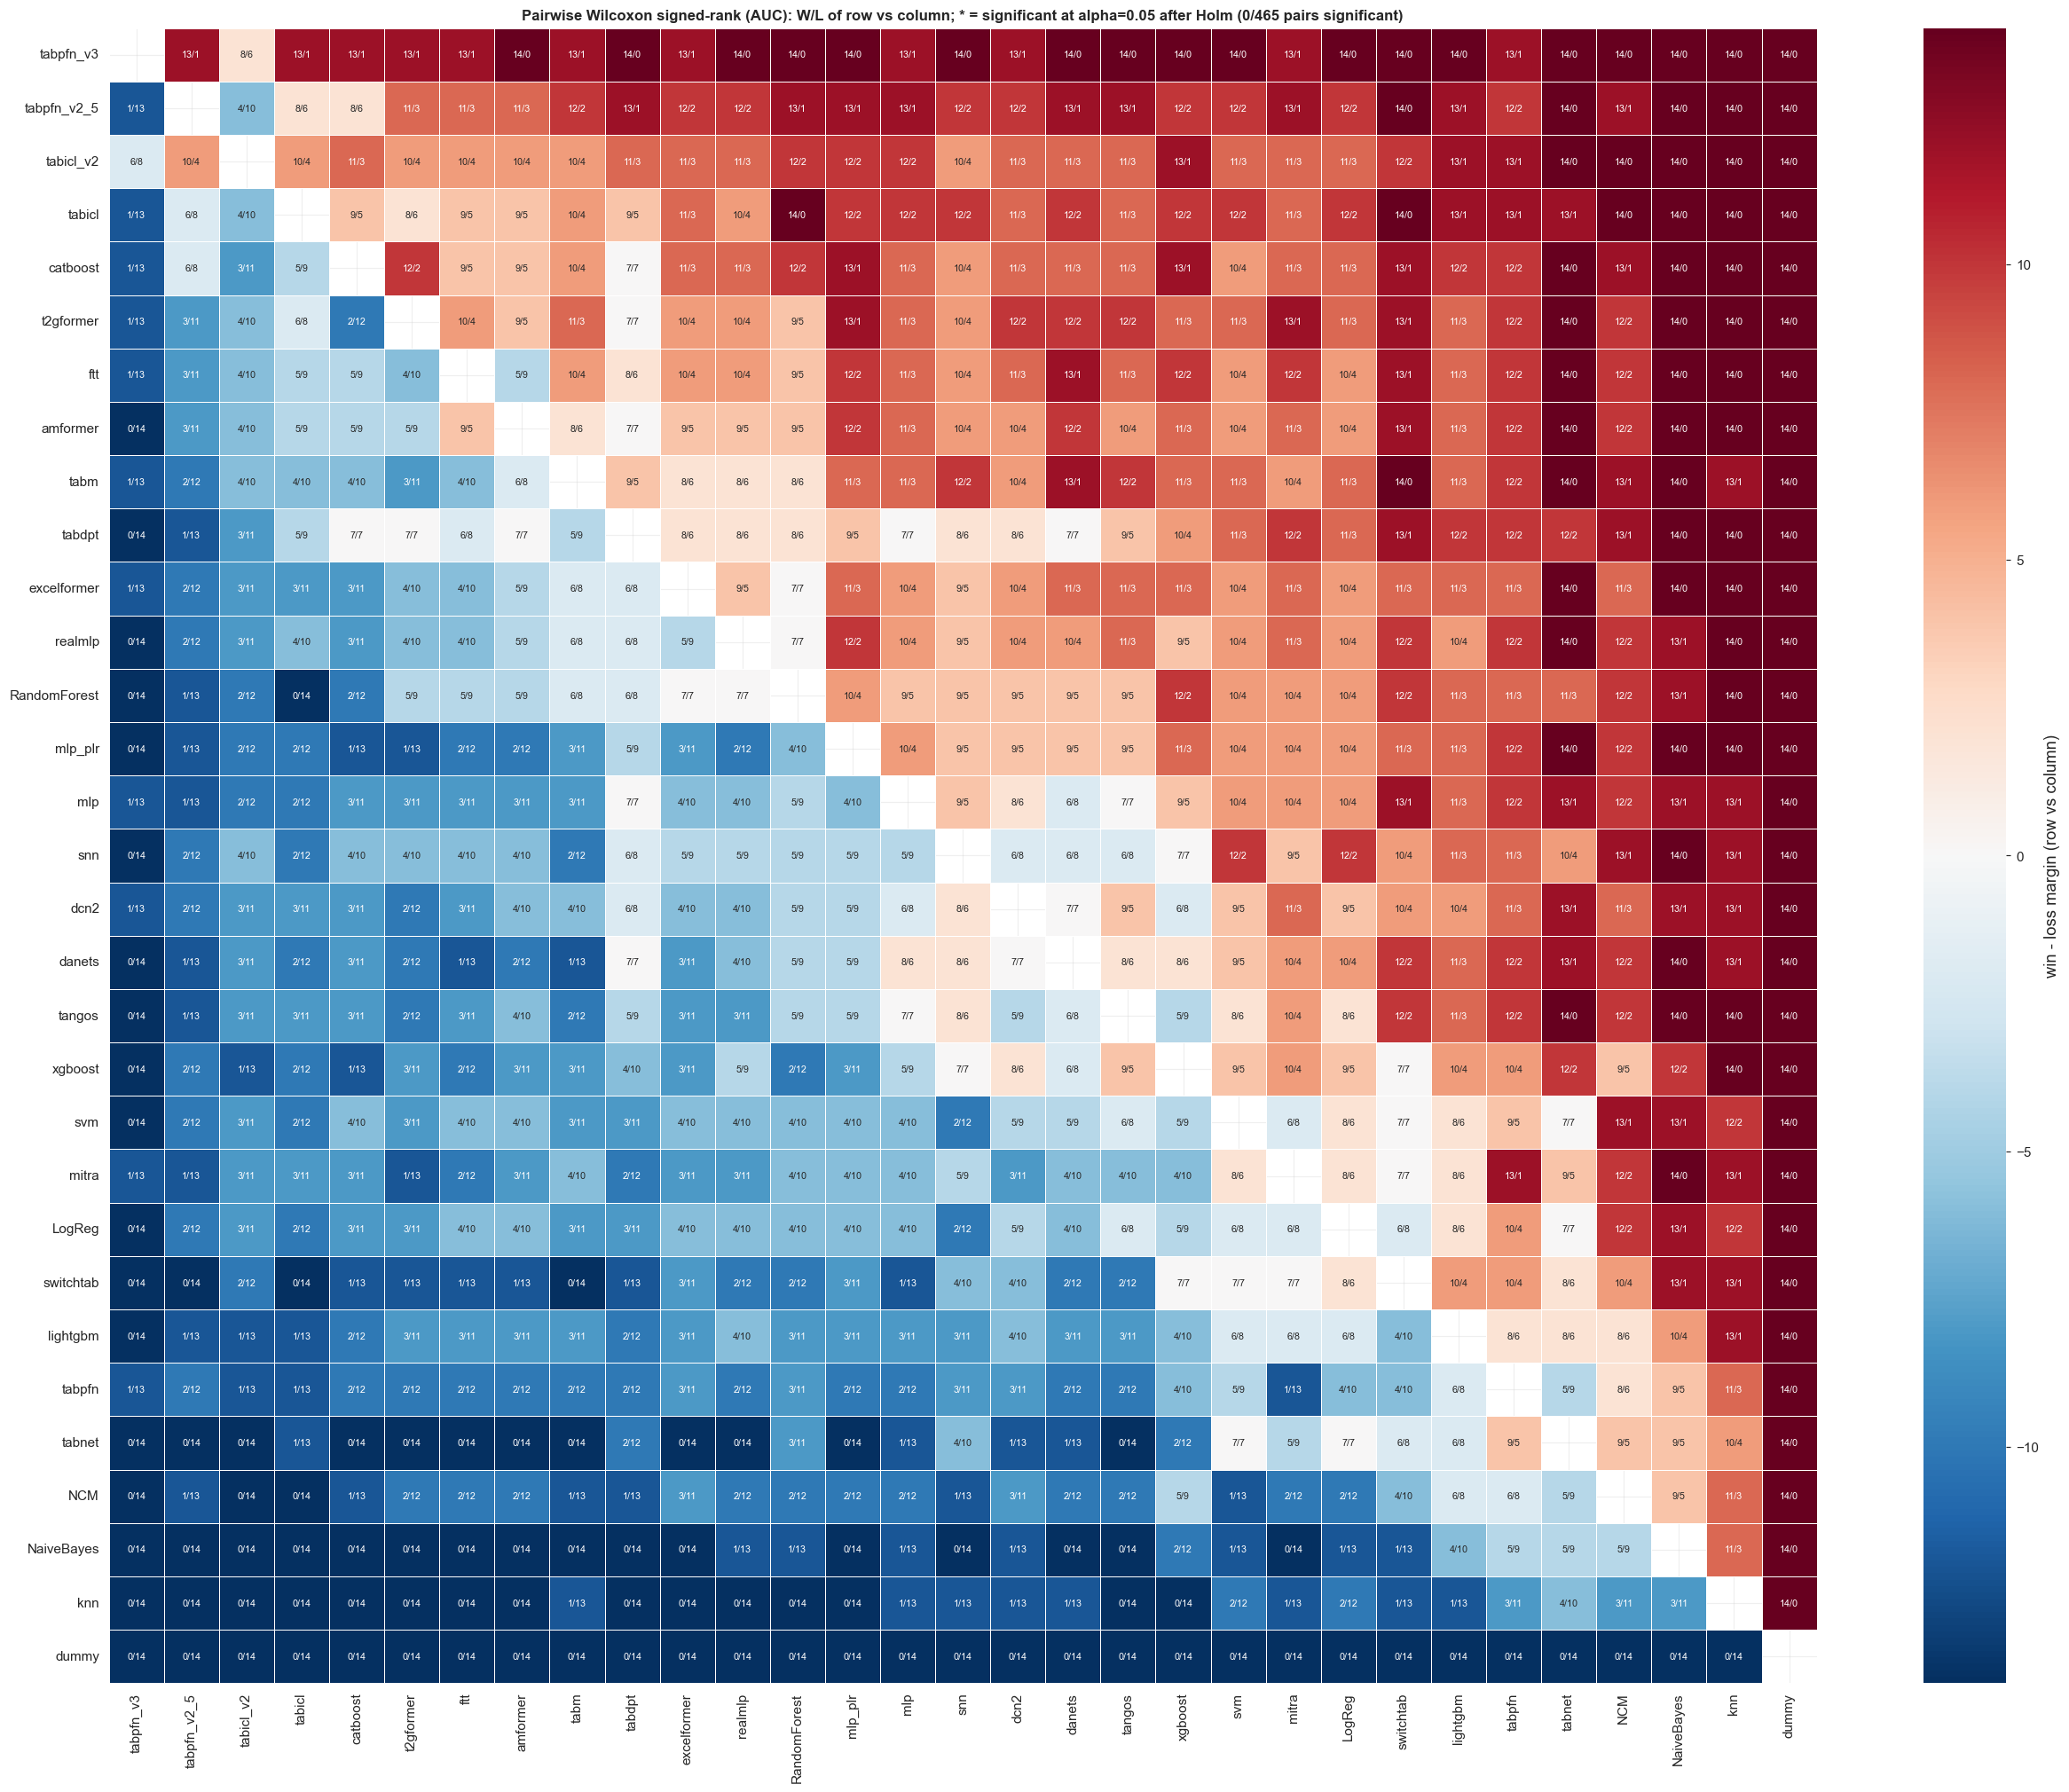

0/465 PD pairs significant after Holm


,method_1,method_2,wins,losses,ties,p_unadjusted,p_holm,significant


In [8]:
st.plot_wilcoxon_wl_matrix(mat_pd, metric_name='AUC',
                           out_path=FIGURES_DIR / 'pd_wilcoxon_wl_auc.pdf')
tab_pd = st.wilcoxon_holm_pairwise(mat_pd)
print(f'{int(tab_pd["significant"].sum())}/{len(tab_pd)} PD pairs significant after Holm')
display(tab_pd[tab_pd['significant']].head(25))

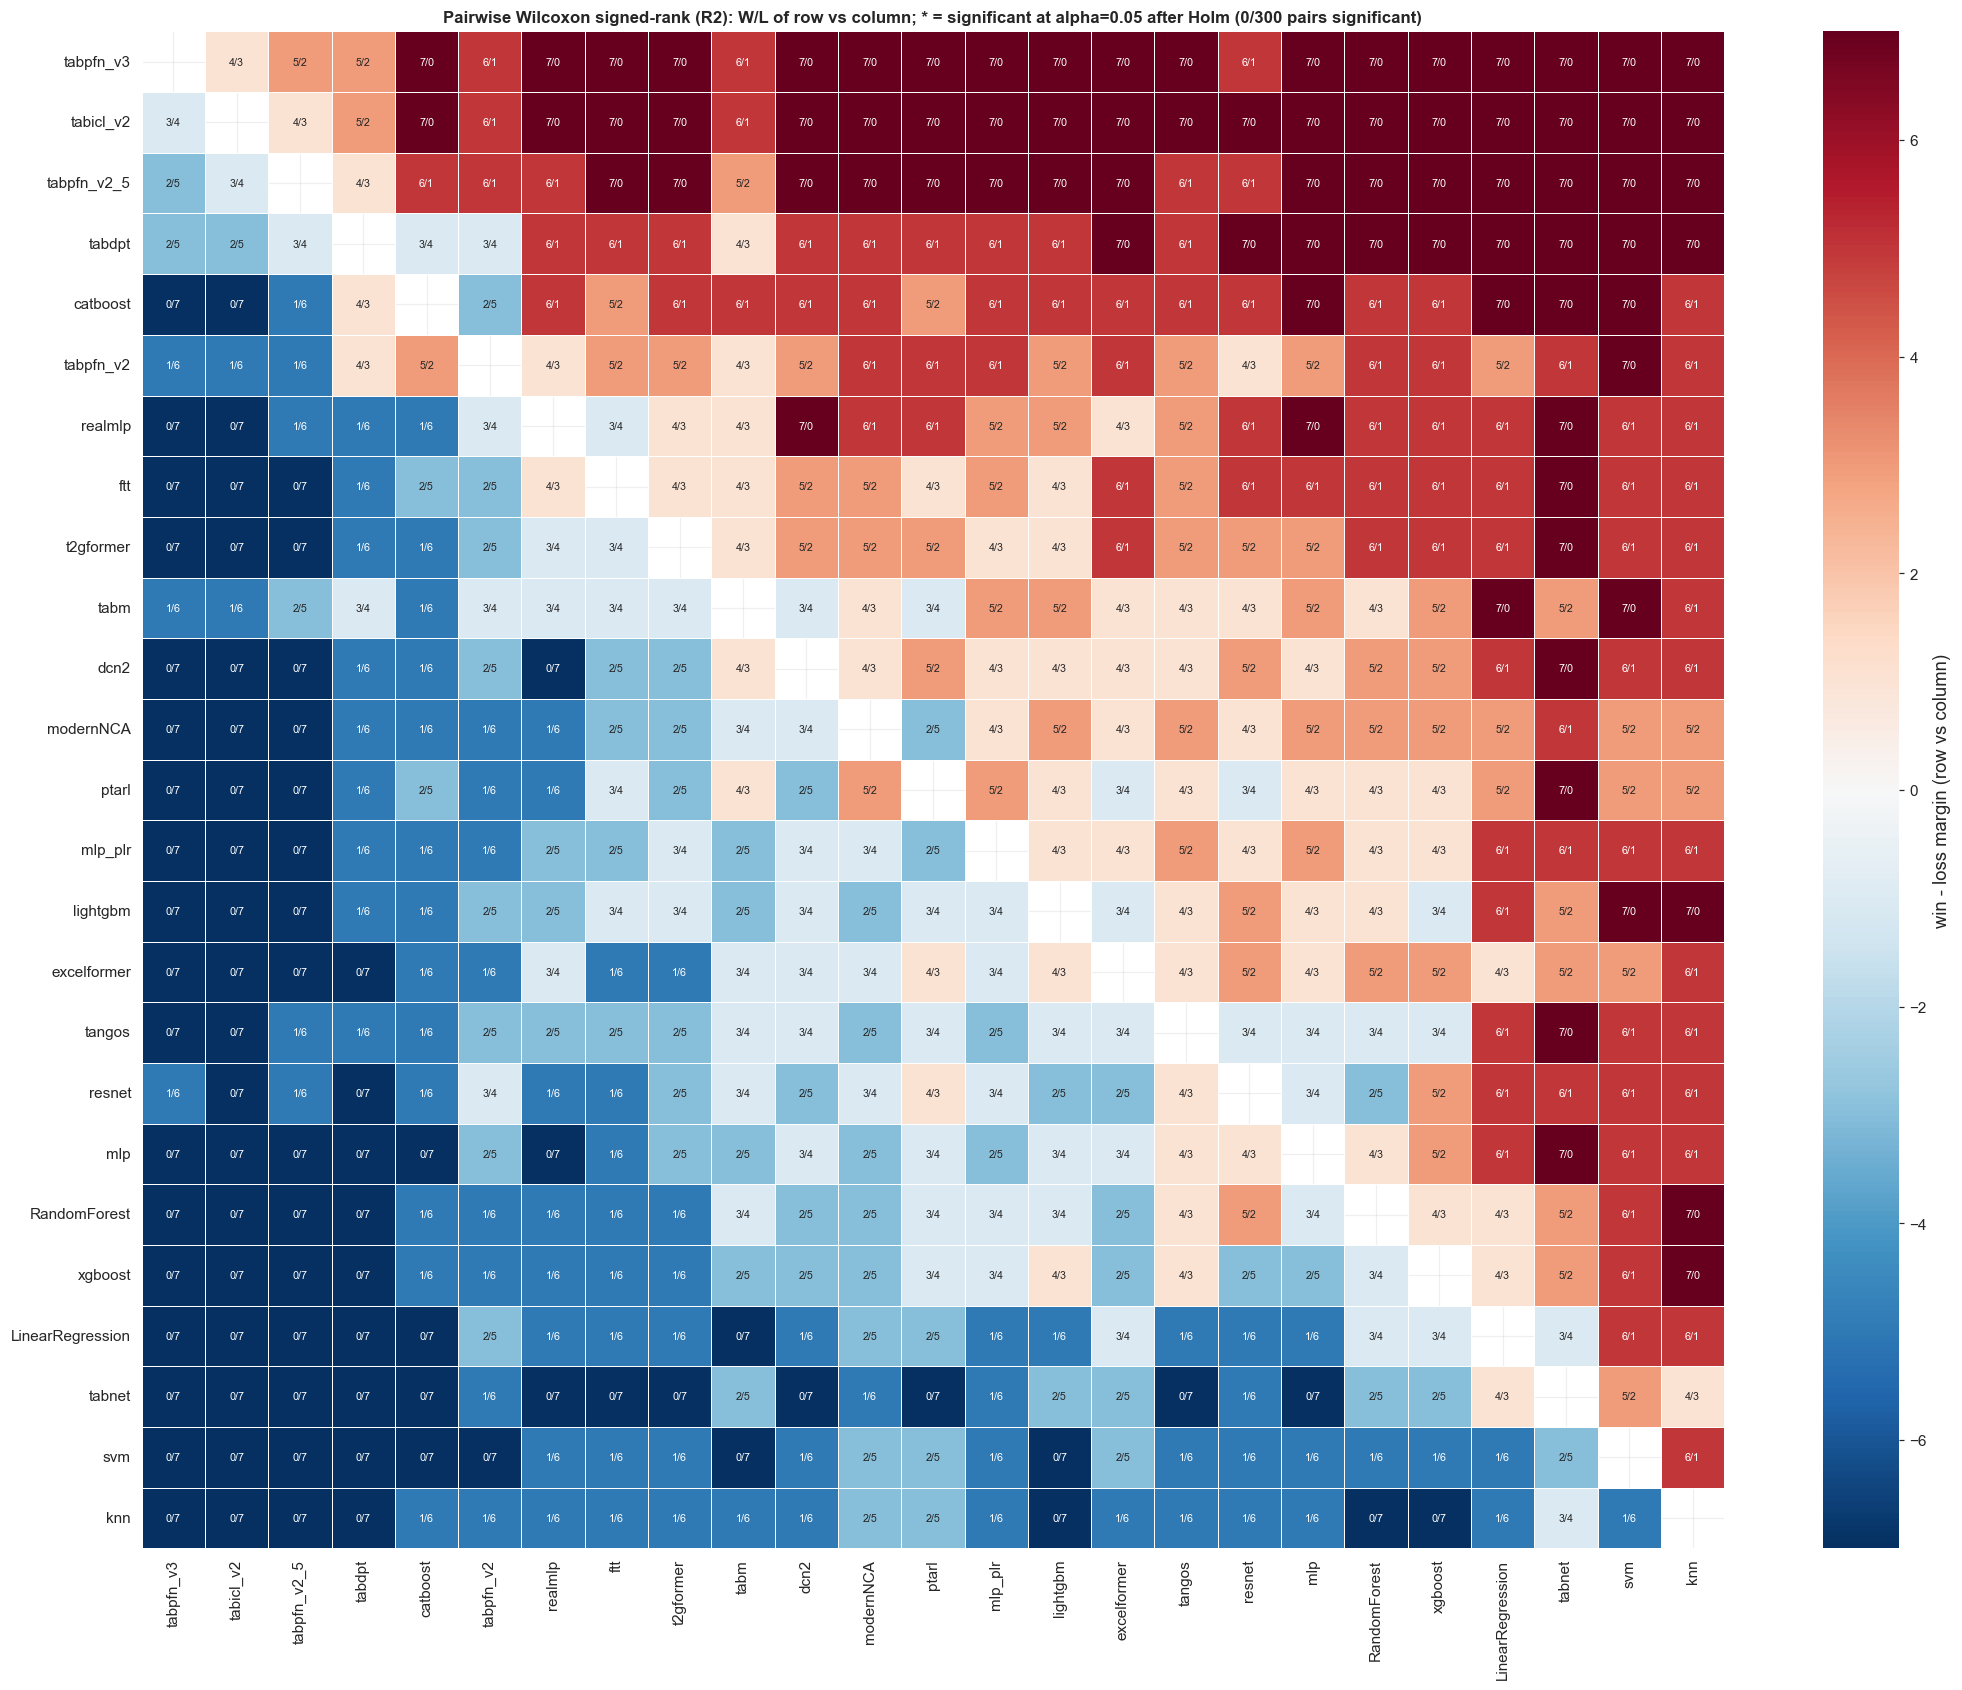

0/300 LGD pairs significant after Holm
note: with N=7 datasets the minimum two-sided Wilcoxon p is 0.016, so after Holm over 300 pairs significance is structurally hard to reach


In [9]:
if df_lgd is not None:
    st.plot_wilcoxon_wl_matrix(mat_lgd, metric_name='R2',
                               out_path=FIGURES_DIR / 'lgd_wilcoxon_wl_r2.pdf')
    tab_lgd = st.wilcoxon_holm_pairwise(mat_lgd)
    n = mat_lgd.shape[0]
    print(f'{int(tab_lgd["significant"].sum())}/{len(tab_lgd)} LGD pairs significant after Holm')
    print(f'note: with N={n} datasets the minimum two-sided Wilcoxon p is {2/2**n:.3f}, '
          f'so after Holm over {len(tab_lgd)} pairs significance is structurally hard to reach')

## Appendix — rank-based post-hoc procedures (Demšar 2006; García & Herrera 2008)
Adjusted p-values from the Friedman rank statistic: one-vs-control step procedures and all-pairwise procedures (Holm, Shaffer static, Bergmann–Hommel where k ≤ 8).

In [10]:
display(st.control_apv_table(mat_pd).head(15))
display(st.pairwise_apv_table(mat_pd).head(15))

,control,method,z,p_unadjusted,bonferroni_dunn,holm,hochberg,hommel,holland,finner,li
0,tabpfn_v3,dummy,8.376466,5.454075e-17,1.636223e-15,1.636223e-15,1.636223e-15,1.636223e-15,0.000000e+00,0.000000e+00,7.387246e-17
1,tabpfn_v3,knn,7.565840,3.853660e-14,1.156098e-12,1.117562e-12,1.117562e-12,1.117562e-12,1.117217e-12,5.778711e-13,5.219572e-14
2,tabpfn_v3,NaiveBayes,7.274846,3.468154e-13,1.040446e-11,9.710830e-12,9.710830e-12,9.710830e-12,9.711343e-12,3.468337e-12,4.697424e-13
3,tabpfn_v3,NCM,6.422650,1.339222e-10,4.017667e-09,3.615901e-09,3.615901e-09,3.481978e-09,3.615900e-09,1.004417e-09,1.813903e-10
4,tabpfn_v3,tabnet,6.360294,2.013678e-10,6.041035e-09,5.235563e-09,5.235563e-09,5.235563e-09,5.235563e-09,1.208207e-09,2.727417e-10
5,tabpfn_v3,tabpfn,6.090086,1.128504e-09,3.385512e-08,2.821260e-08,2.821260e-08,2.821260e-08,2.821260e-08,5.642519e-09,1.528497e-09
6,tabpfn_v3,lightgbm,5.570454,2.540769e-08,7.622307e-07,6.097846e-07,6.097846e-07,5.843769e-07,6.097844e-07,1.088901e-07,3.441332e-08
7,tabpfn_v3,switchtab,5.528883,3.222760e-08,9.668280e-07,7.412348e-07,7.412348e-07,7.412348e-07,7.412345e-07,1.208535e-07,4.365052e-08
8,tabpfn_v3,LogReg,4.988466,6.086063e-07,1.825819e-05,1.338934e-05,1.338934e-05,1.217213e-05,1.338925e-05,2.028686e-06,8.243233e-07
9,tabpfn_v3,mitra,4.905325,9.327284e-07,2.798185e-05,1.958730e-05,1.958730e-05,1.865457e-05,1.958711e-05,2.798182e-06,1.263328e-06


[stat] Bergmann-Hommel skipped (k=31 > 8; exhaustive-set enumeration infeasible) -- use Shaffer instead.


,method_1,method_2,z,p_unadjusted,nemenyi,holm,shaffer,bergmann_hommel
0,tabpfn_v3,dummy,-8.376466,5.454075e-17,2.536145e-14,2.536145e-14,2.536145e-14,NaN
1,tabpfn_v3,knn,-7.565840,3.853660e-14,1.791952e-11,1.788098e-11,1.676342e-11,NaN
2,tabpfn_v3,NaiveBayes,-7.274846,3.468154e-13,1.612691e-10,1.605755e-10,1.508647e-10,NaN
3,tabpfn_v2_5,dummy,-7.254061,4.044581e-13,1.880730e-10,1.868596e-10,1.759393e-10,NaN
4,tabicl_v2,dummy,-7.129349,1.008445e-12,4.689271e-10,4.648934e-10,4.386738e-10,NaN
5,tabicl,dummy,-6.776000,1.235490e-11,5.745030e-09,5.683255e-09,5.374383e-09,NaN
6,catboost,dummy,-6.526576,6.729005e-11,3.128987e-08,3.088613e-08,2.927117e-08,NaN
7,tabpfn_v2_5,knn,-6.443435,1.167992e-10,5.431161e-08,5.349401e-08,5.080763e-08,NaN
8,tabpfn_v3,NCM,-6.422650,1.339222e-10,6.227384e-08,6.120246e-08,5.825618e-08,NaN
9,tabpfn_v3,tabnet,-6.360294,2.013678e-10,9.363604e-08,9.182373e-08,8.759500e-08,NaN


> **Interpretation guide.** PAMA describes *practical dominance frequency*; the Friedman test establishes that rank differences are *globally* non-random; the Wilcoxon–Holm matrix *localizes* which pairs differ. Few significant pairs with small N is expected — the omnibus test has far more power to detect global heterogeneity than pairwise tests have to localize it (see the power note printed above for LGD).